> **Author:** Brendan OConnell  
> **Year:** 2026  
> **Purpose:**   
> **Key decisions:**  
> *   
> * 

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    f1_score,
)
import matplotlib.pyplot as plt
import warnings

import shap

import seaborn as sns
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
import xgboost as xgb
from sklearn.metrics import (
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")

c:\git\datascience-capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# NN Learning Curve (train vs. val) --- No Overfitting plot

## Group-Aware Train/Val/Test Split

## MLP Architecture (Tunable)

## Retrain Best Model

# XGB Learning Curve (train vs. val) --- No Overfitting plot

In [2]:
# custom functions


def sentinel_divide(n, d):
    sentinel = -1
    safe_d = np.where(d == 0, sentinel, d)
    return n / safe_d

In [3]:
df = pd.read_parquet("../../data/processed/preprocessed_minimal.parquet")
df.shape

(2294985, 94)

In [4]:
# NFI column sort
nfi_meta = ["stub_id", "particle_id", "class", "label", "target"]
element_cols = [c for c in df.columns if c not in nfi_meta]
gsr = ["pb", "sb", "ba"]
non_gsr = sorted([c for c in element_cols if c not in gsr])
nfi_df = df[nfi_meta + gsr + non_gsr]

print(f"# of elements: {len(element_cols)}")

# of elements: 89


In [5]:
eng_df = nfi_df.copy()

# Pb * Sb
eng_df["pb_times_sb"] = eng_df["pb"] * (eng_df["sb"])

# Log (Pb + Sb)
# eng_df["log_pb_plus_sb"] = np.log1p(eng_df["pb"] + eng_df["sb"])

# GSR ratios over total mass
total_mass = eng_df[element_cols].sum(axis=1)
total_mass_no_sb = total_mass - eng_df["sb"]
total_mass_no_ba = total_mass - eng_df["ba"]
total_mass_no_pb = total_mass - eng_df["pb"]

eng_df["pb_ba_over_non_sb_mass"] = (eng_df["pb"] + eng_df["ba"]) / total_mass_no_sb
eng_df["pb_sb_over_non_ba_mass"] = (eng_df["pb"] + eng_df["sb"]) / total_mass_no_ba
eng_df["ba_sb_over_non_pb_mass"] = (eng_df["ba"] + eng_df["sb"]) / total_mass_no_pb

# Brass particles
eng_df["cu_zn_over_mass"] = (eng_df["cu"] + eng_df["zn"]) / total_mass

# Titanium Zinc
eng_df["ti_zn_over_mass"] = (eng_df["ti"] + eng_df["zn"]) / total_mass

# Non-Barium GSR over Non-Barium Confounders
gsr = eng_df["pb"] + eng_df["sb"]
confounders = (
    eng_df["ca"] + eng_df["si"] + eng_df["al"] + eng_df["fe"]
)  # + eng_df['ti'] + eng_df['zn'] + eng_df['cu']
eng_df["gsr_over_confounders"] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_df["gsr_over_confounders"]) | eng_df["gsr_over_confounders"].isna())

False

In [6]:
eng_cols = [c for c in eng_df.columns if c not in nfi_meta + element_cols]
print(f"# of engineered features: {len(eng_cols)}")
print(f"\nEngineered features:")
for feat in eng_cols:
    print(f"\t{feat}")

# of engineered features: 7

Engineered features:
	pb_times_sb
	pb_ba_over_non_sb_mass
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


In [7]:
feature_cols = element_cols + eng_cols
print(f"# of feature columns: {len(feature_cols)}")

# of feature columns: 96


In [8]:
X = eng_df[feature_cols].values.astype(np.float32)
y = eng_df["target"].values.astype(np.float32)
groups = eng_df["stub_id"].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(
    n_splits=1, test_size=0.25, random_state=42
)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

groups_train = set(groups_trainval[train_idx_rel])
groups_val = set(groups_trainval[val_idx_rel])
groups_test = set(groups[test_idx])

In [9]:
# Verify no stub leakage
assert len(groups_train & groups_val) == 0, "Train-Val stub leak!"
assert len(groups_train & groups_test) == 0, "Train-Test stub leak!"
assert len(groups_val & groups_test) == 0, "Val-Test stub leak!"

print("No stub-level leakage")

No stub-level leakage


In [10]:
total_obs = len(y_train) + len(y_val) + len(y_test)

summary = pd.DataFrame(
    {
        "Split": ["Train", "Val", "Test"],
        "Observations": [len(y_train), len(y_val), len(y_test)],
        "% of Total": [
            len(y_train) / total_obs * 100,
            len(y_val) / total_obs * 100,
            len(y_test) / total_obs * 100,
        ],
        "GSR (target=1)": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
        "GSR %": [y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100],
        "Unique Stubs": [len(groups_train), len(groups_val), len(groups_test)],
    }
)

summary["% of Total"] = summary["% of Total"].map("{:.1f}%".format)
summary["GSR %"] = summary["GSR %"].map("{:.2f}%".format)

print(f"Total observations : {total_obs:,}")
print(f"Total features     : {X_train.shape[1]}")
print(f"Total unique stubs : {len(groups_train | groups_val | groups_test):,}\n")
print(summary.to_string(index=False))

Total observations : 2,294,985
Total features     : 96
Total unique stubs : 3,786

Split  Observations % of Total  GSR (target=1)  GSR %  Unique Stubs
Train       1444147      62.9%          717835 49.71%          2271
  Val        407614      17.8%          151162 37.08%           757
 Test        443224      19.3%          209949 47.37%           758


In [11]:
baseline = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="aucpr",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)

baseline.fit(
    X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=10
)

[0]	validation_0-aucpr:0.99907	validation_1-aucpr:0.99926
[10]	validation_0-aucpr:0.99990	validation_1-aucpr:0.99994
[20]	validation_0-aucpr:0.99996	validation_1-aucpr:0.99998
[30]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99999
[40]	validation_0-aucpr:0.99999	validation_1-aucpr:1.00000
[50]	validation_0-aucpr:0.99999	validation_1-aucpr:1.00000
[60]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[70]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[80]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[90]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[99]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [12]:
results = baseline.evals_result()
train_aucpr = results["validation_0"]["aucpr"]
val_aucpr = results["validation_1"]["aucpr"]

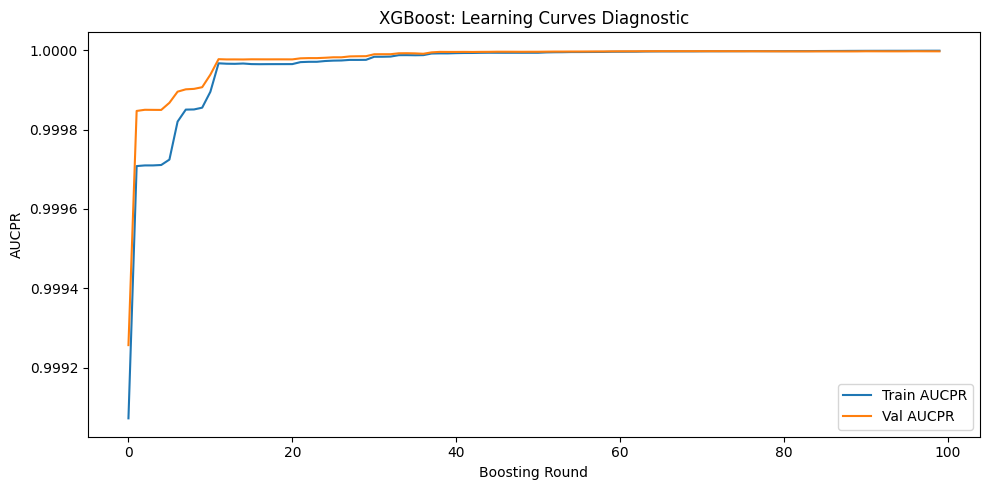

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_aucpr, label="Train AUCPR")
ax.plot(val_aucpr, label="Val AUCPR")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("AUCPR")
ax.set_title("XGBoost: Learning Curves Diagnostic")
ax.legend()
plt.tight_layout()
plt.savefig(
    "outputs/overfitting_ablation_ambiguous__xgb_learning_curves_final.png", dpi=150
)
plt.show()

# Plots to Check for Overfitting & Ablation

NameError: name 'train_losses' is not defined

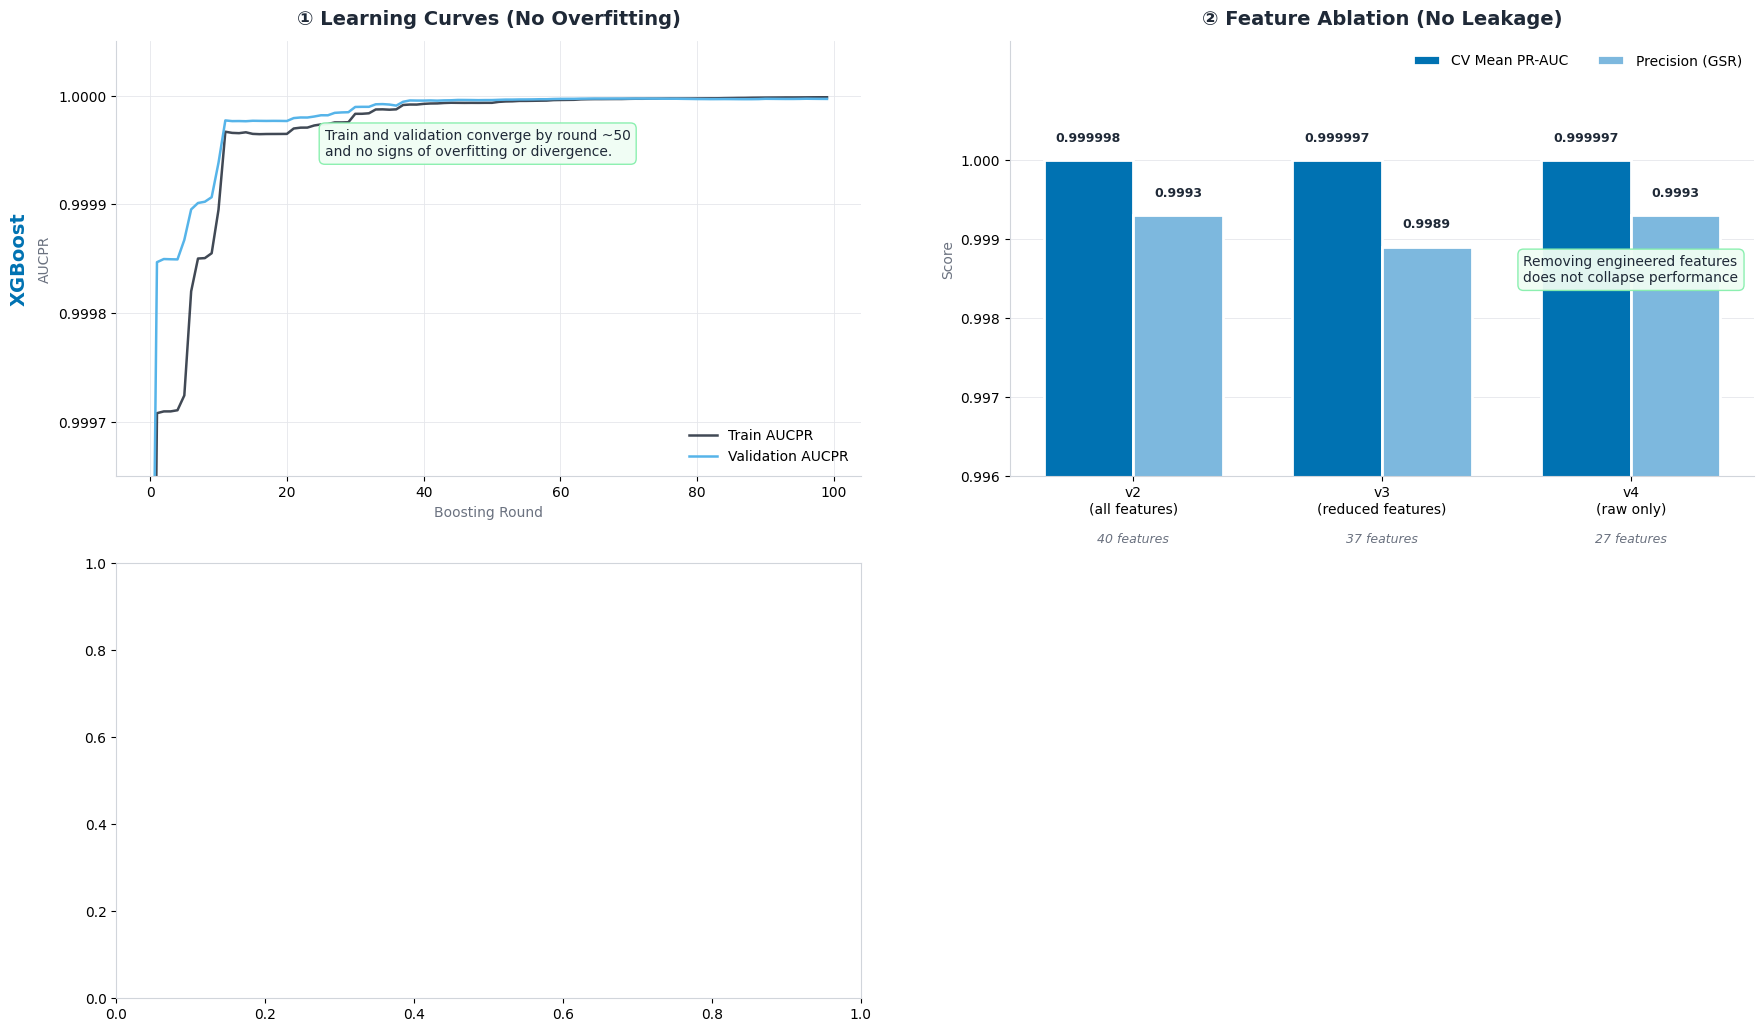

In [14]:
# ---------- Colors ----------
XGB_COLOR = "#0072B2"  # Okabe-Ito blue
NN_COLOR = "#CC79A7"  # Okabe-Ito magenta
TRAIN_COLOR = "#1F2937"  # near-black for train line
VAL_COLOR_XGB = "#56B4E9"  # sky blue for XGB validation
VAL_COLOR_NN = "#F0A0CC"  # lighter pink for NN validation
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.edgecolor": "#D1D5DB",
    }
)

# --- XGB ablation: v2 / v3 / v4 with CV Mean PR-AUC and Precision (GSR) ---
xgb_ablation = {
    "v2\n(all features)": {"pr_auc": 0.999998, "precision": 0.9993, "features": 40},
    "v3\n(reduced features)": {"pr_auc": 0.999997, "precision": 0.9989, "features": 37},
    "v4\n(raw only)": {"pr_auc": 0.999997, "precision": 0.9993, "features": 27},
}

# --- NN ablation: A/B/C/D with PR-AUC and ROC-AUC ---
nn_ablation = {
    "A: Full\n(all features)": {"pr_auc": 1.0000, "roc_auc": 1.0000, "features": 56},
    "B: CLR only": {"pr_auc": 0.9999, "roc_auc": 0.9999, "features": 27},
    "C: Raw + presence": {"pr_auc": 0.9999, "roc_auc": 0.9999, "features": 54},
    "D: Raw only": {"pr_auc": 0.9998, "roc_auc": 0.9999, "features": 27},
}

# Figure
fig = plt.figure(figsize=(18, 11), facecolor="white")
gs = GridSpec(
    nrows=2,
    ncols=2,
    height_ratios=[1.0, 1.0],
    hspace=0.20,
    wspace=0.20,
    left=0.06,
    right=0.97,
    top=0.93,
    bottom=0.06,
)

# Row 1, Col 1 XGBoost learning curve
ax = fig.add_subplot(gs[0, 0])
ax.set_title(
    "① Learning Curves (No Overfitting)",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=12,
    loc="center",
)
ax.plot(train_aucpr, color=TRAIN_COLOR, linewidth=1.8, label="Train AUCPR", alpha=0.85)
ax.plot(val_aucpr, color=VAL_COLOR_XGB, linewidth=1.8, label="Validation AUCPR")
ax.set_xlabel("Boosting Round", fontsize=10, color=MUTED)
ax.set_ylabel("AUCPR", fontsize=10, color=MUTED)
ax.set_ylim(0.99965, 1.00005)
ax.set_yticks([0.9997, 0.9998, 0.9999, 1.0000])
ax.set_yticklabels(["0.9997", "0.9998", "0.9999", "1.0000"])
ax.legend(loc="lower right", fontsize=10, frameon=False)
ax.grid(True, color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    -0.13,
    0.5,
    "XGBoost",
    rotation=90,
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color=XGB_COLOR,
    transform=ax.transAxes,
)

ax.text(
    0.28,
    0.73,
    "Train and validation converge by round ~50\nand no signs of overfitting or divergence.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color=INK,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#F0FDF4",
        edgecolor="#86EFAC",
        linewidth=1,
        alpha=0.95,
    ),
)

# Row 1, Col 2 XGBoost ablation
ax = fig.add_subplot(gs[0, 1])
ax.set_title(
    "② Feature Ablation (No Leakage)",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=12,
    loc="center",
)
labels_xgb = list(xgb_ablation.keys())
pr_xgb = [xgb_ablation[k]["pr_auc"] for k in labels_xgb]
acc_xgb = [xgb_ablation[k]["precision"] for k in labels_xgb]
feats_xgb = [xgb_ablation[k]["features"] for k in labels_xgb]

XGB_LIGHT = "#7DB8DE"
x_pos = np.arange(len(labels_xgb))
bar_w = 0.36

bars_pr = ax.bar(
    x_pos - bar_w / 2,
    pr_xgb,
    bar_w,
    color=XGB_COLOR,
    edgecolor="white",
    linewidth=2,
    label="CV Mean PR-AUC",
)
bars_acc = ax.bar(
    x_pos + bar_w / 2,
    acc_xgb,
    bar_w,
    color=XGB_LIGHT,
    edgecolor="white",
    linewidth=2,
    label="Precision (GSR)",
)

for bar, val in zip(bars_pr, pr_xgb):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.0002,
        f"{val:.6f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=INK,
    )
for bar, val in zip(bars_acc, acc_xgb):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.0002,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=INK,
    )

for xpos, n in zip(x_pos, feats_xgb):
    ax.text(
        xpos,
        -0.13,
        f"{n} features",
        ha="center",
        va="top",
        fontsize=9,
        color=MUTED,
        style="italic",
        transform=ax.get_xaxis_transform(),
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_xgb, fontsize=10)
ax.set_ylabel("Score", fontsize=10, color=MUTED)
ax.set_ylim(0.996, 1.0015)
ax.set_yticks([0.996, 0.997, 0.998, 0.999, 1.000])
ax.set_yticklabels(["0.996", "0.997", "0.998", "0.999", "1.000"])
ax.legend(loc="upper right", fontsize=10, frameon=False, ncol=2)
ax.grid(True, axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.69,
    0.44,
    "Removing engineered features\ndoes not collapse performance",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color=INK,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#F0FDF4",
        edgecolor="#86EFAC",
        linewidth=1,
        alpha=0.95,
    ),
)

# Row 2, Col 1 Neural Net learning curve
ax = fig.add_subplot(gs[1, 0])
ax.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    color=TRAIN_COLOR,
    linewidth=1.8,
    marker="o",
    markersize=4,
    label="Train Loss",
    alpha=0.85,
)
ax.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    color=VAL_COLOR_NN,
    linewidth=1.8,
    marker="s",
    markersize=4,
    label="Validation Loss",
)
ax.set_xlabel("Epoch", fontsize=10, color=MUTED)
ax.set_ylabel("BCE Loss", fontsize=10, color=MUTED)
ax.set_ylim(0, 0.028)
ax.legend(loc="upper right", fontsize=10, frameon=False)
ax.grid(True, color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    -0.13,
    0.5,
    "Neural Net",
    rotation=90,
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color=NN_COLOR,
    transform=ax.transAxes,
)

ax.text(
    0.57,
    0.20,
    "Validation tracks train tightly;\nno sign of overfitting or divergence.",
    transform=ax.transAxes,
    ha="left",
    va="center",
    fontsize=10,
    color=INK,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#F0FDF4",
        edgecolor="#86EFAC",
        linewidth=1,
        alpha=0.95,
    ),
)

# Row 2, Col 2 NN ablation
ax = fig.add_subplot(gs[1, 1])
labels_nn = list(nn_ablation.keys())
vals_nn = [nn_ablation[k]["pr_auc"] for k in labels_nn]
acc_nn = [nn_ablation[k]["roc_auc"] for k in labels_nn]
feats_nn = [nn_ablation[k]["features"] for k in labels_nn]

NN_LIGHT = "#E6BFD6"
x_pos_nn = np.arange(len(labels_nn))
bar_w = 0.36

bars_pr = ax.bar(
    x_pos_nn - bar_w / 2,
    vals_nn,
    bar_w,
    color=NN_COLOR,
    edgecolor="white",
    linewidth=2,
    label="PR-AUC",
)
bars_acc = ax.bar(
    x_pos_nn + bar_w / 2,
    acc_nn,
    bar_w,
    color=NN_LIGHT,
    edgecolor="white",
    linewidth=2,
    label="ROC-AUC",
)

for bar, val in zip(bars_pr, vals_nn):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.0002,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=INK,
    )
for bar, val in zip(bars_acc, acc_nn):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.0002,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=INK,
    )

for xpos, n in zip(x_pos_nn, feats_nn):
    ax.text(
        xpos,
        -0.13,
        f"{n} features",
        ha="center",
        va="top",
        fontsize=9,
        color=MUTED,
        style="italic",
        transform=ax.get_xaxis_transform(),
    )

ax.set_xticks(x_pos_nn)
ax.set_xticklabels(labels_nn, fontsize=10)
ax.set_ylabel("Score", fontsize=10, color=MUTED)
ax.set_ylim(0.9996, 1.0015)
ax.set_yticks([0.996, 0.997, 0.998, 0.999, 1.000])
ax.set_yticklabels(["0.996", "0.997", "0.998", "0.999", "1.000"])
ax.legend(loc="upper right", fontsize=10, frameon=False, ncol=2)
ax.grid(True, axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.51,
    0.58,
    "Performance stays high;\nthe signal is real.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color=INK,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#F0FDF4",
        edgecolor="#86EFAC",
        linewidth=1,
        alpha=0.95,
    ),
)

plt.savefig(
    "outputs/overfitting_ablation_ambiguous__learning_curves_no_overfitting.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# Ambiguous Particles

## NN

The 506,682 ambiguous particles (Pb, Ba, Sb, Sr single-element classes) were excluded from training. Now we score them with the trained model to see how confidently it assigns them to GSR or Non-GSR. This directly addresses our research question about where automated classification breaks down and which particles need expert review.

## XGB

In [ ]:
nfi_df = pd.read_parquet("../../data/raw/NFI/nfi_particle_data_full.parquet")
nfi_df.shape

(2801667, 106)

In [ ]:
element_cols = [c for c in nfi_df.columns if 1 <= len(c) <= 2]
filtered = nfi_df[["stub_id", "particle_id", "merged_relevance_class"] + element_cols]
filtered = filtered.drop(columns="id")  # remove 'id' if it was included
element_cols = [c for c in filtered.columns if 1 <= len(c) <= 2]
len(element_cols)

89

In [ ]:
amb_89 = filtered[
    filtered["merged_relevance_class"].isin(
        ["Sb", "Pb", "Ba", "Sr", "BaSi", "BaSn", "BaSr"]
    )
]
amb_89.shape

(506682, 92)

In [ ]:
amb_89 = amb_89.rename(columns={"merged_relevance_class": "final_class"}).assign(
    final_class=lambda d: d["final_class"].replace({"BaSn": "Ba"})
)

print(amb_89["final_class"].value_counts())

final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


In [ ]:
amb_89["label"] = "Ambiguous"

In [ ]:
df_amb = pd.read_parquet("../../data/processed/particle_ambiguous.parquet")
print(f"Ambiguous particles: {len(df_amb):,}")
print(f"Class distribution:")
print(df_amb["final_class"].value_counts())

Ambiguous particles: 506,682
Class distribution:
final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


__Rejoin original ambiguous dataset w/ preprocessed ambiguous dataset (all 89 elements)__

In [ ]:
keys = ["stub_id", "particle_id"]
drop_extra = ["relevance_class", "merged_relevance_class"]

# columns in df_amb that overlap with amb_89 (other than the keys) -> drop from df_amb to avoid dupes
overlap = [c for c in df_amb.columns if c in amb_89.columns and c not in keys]
df_amb_trim = df_amb.drop(columns=overlap)

merged = amb_89.merge(df_amb_trim, on=keys, how="inner")
merged = merged.drop(columns=[c for c in drop_extra if c in merged.columns])
print(f"Merged dataset shape: {merged.shape}")

Merged dataset shape: (506682, 93)


In [ ]:
amb_meta_cols = ["stub_id", "particle_id", "final_class", "label"]
amb_element_cols = [c for c in merged.columns if c not in amb_meta_cols]
len(amb_element_cols)

89

In [ ]:
eng_amb = merged.copy()

# Pb * Sb
eng_amb["pb_times_sb"] = eng_amb["pb"] * (eng_amb["sb"])

# Log (Pb + Sb)
# eng_amb["log_pb_plus_sb"] = np.log1p(eng_amb["pb"] + eng_amb["sb"])

# GSR ratios over total mass
total_mass = eng_amb[element_cols].sum(axis=1)
total_mass_no_sb = total_mass - eng_amb["sb"]
total_mass_no_ba = total_mass - eng_amb["ba"]
total_mass_no_pb = total_mass - eng_amb["pb"]

eng_amb["pb_ba_over_non_sb_mass"] = (eng_amb["pb"] + eng_amb["ba"]) / total_mass_no_sb
eng_amb["pb_sb_over_non_ba_mass"] = (eng_amb["pb"] + eng_amb["sb"]) / total_mass_no_ba
eng_amb["ba_sb_over_non_pb_mass"] = (eng_amb["ba"] + eng_amb["sb"]) / total_mass_no_pb

# Brass particles
eng_amb["cu_zn_over_mass"] = (eng_amb["cu"] + eng_amb["zn"]) / total_mass

# Titanium Zinc
eng_amb["ti_zn_over_mass"] = (eng_amb["ti"] + eng_amb["zn"]) / total_mass

# Non-Barium GSR over Non-Barium Confounders
gsr = eng_amb["pb"] + eng_amb["sb"]
confounders = (
    eng_amb["ca"] + eng_amb["si"] + eng_amb["al"] + eng_amb["fe"]
)  # + eng_amb['ti'] + eng_amb['zn'] + eng_amb['cu']
eng_amb["gsr_over_confounders"] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_amb["gsr_over_confounders"]) | eng_amb["gsr_over_confounders"].isna())

False

In [ ]:
eng_amb_cols = [c for c in eng_amb.columns if c not in amb_meta_cols + amb_element_cols]
print(f"# of engineered features: {len(eng_amb_cols)}")
print(f"\nEngineered features:")
for feat in eng_amb_cols:
    print(f"\t{feat}")

# of engineered features: 8

Engineered features:
	pb_times_sb
	log_pb_plus_sb
	pb_ba_over_non_sb_mass
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


In [ ]:
feature_amb_cols = amb_element_cols + eng_amb_cols
print(f"# of feature columns: {len(feature_amb_cols)}")

# of feature columns: 97


__Run XGBoost Model against Ambiguous Particles__

In [ ]:
xgb_model = baseline
X_amb = eng_amb[feature_amb_cols].values.astype(np.float32)

probs_amb = xgb_model.predict_proba(X_amb)[:, 1]
preds_amb = (probs_amb >= 0.94).astype(int)

eng_amb = eng_amb.assign(prob_gsr=probs_amb, pred_gsr=preds_amb)

n = len(eng_amb)
n_gsr = int(preds_amb.sum())
print(f"Particles scored : {n:,}")
print(f"Predicted GSR    : {n_gsr:,}  ({n_gsr / n:.1%})")
print(f"Predicted Non-GSR: {n - n_gsr:,}  ({1 - n_gsr / n:.1%})")
print(f"\nProbability distribution:")
print(
    pd.Series(probs_amb)
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
    .round(4)
)
print(f"\nPredicted GSR by final_class:")
agg = eng_amb.groupby("final_class").agg(
    n=("pred_gsr", "size"), pred_gsr=("pred_gsr", "sum"), mean_prob=("prob_gsr", "mean")
)
agg["pct_gsr"] = agg["pred_gsr"] / agg["n"] * 100
agg = agg.sort_values("pct_gsr", ascending=False)
print(agg.round(2))

Particles scored : 506,682
Predicted GSR    : 22,016  (4.3%)
Predicted Non-GSR: 484,666  (95.7%)

Probability distribution:
count    506682.0000
mean          0.2958
std           0.3593
min           0.0000
10%           0.0000
25%           0.0005
50%           0.1032
75%           0.6960
90%           0.8831
95%           0.9304
max           1.0000
dtype: float64

Predicted GSR by final_class:
                  n  pred_gsr  mean_prob  pct_gsr
final_class                                      
Sb           225676     21006       0.57     9.31
Pb           168334       710       0.13     0.42
Ba            89277       298       0.00     0.33
Sr            23395         2       0.00     0.01


In [ ]:
print(f"Overall pct_gsr (manual): {eng_amb['pred_gsr'].mean() * 100:.2f}%")
print(
    f"Weighted from agg:        {(agg['pred_gsr'].sum() / agg['n'].sum()) * 100:.2f}%"
)
print(agg[["n", "pred_gsr", "pct_gsr"]])

Overall pct_gsr (manual): 4.35%
Weighted from agg:        4.35%
                  n  pred_gsr   pct_gsr
final_class                            
Sb           225676     21006  9.308035
Pb           168334       710  0.421781
Ba            89277       298  0.333793
Sr            23395         2  0.008549


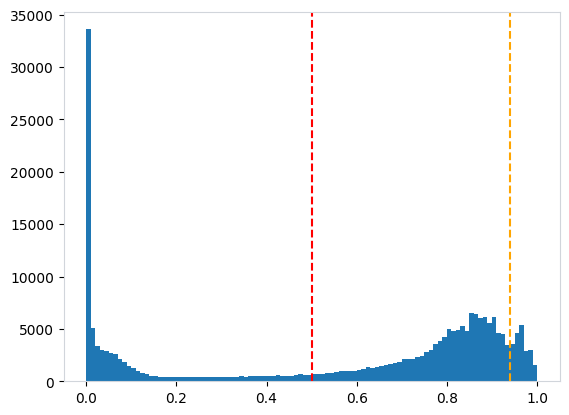

In [ ]:
sb_mask = eng_amb["final_class"] == "Sb"
sb_flagged = eng_amb[sb_mask & (eng_amb["pred_gsr"] == 1)]
sb_not_flagged = eng_amb[sb_mask & (eng_amb["pred_gsr"] == 0)]

sb_probs = probs_amb[sb_mask]
plt.hist(sb_probs, bins=100)
plt.axvline(0.5, color="red", linestyle="--")
plt.axvline(0.94, color="orange", linestyle="--", label="your threshold")

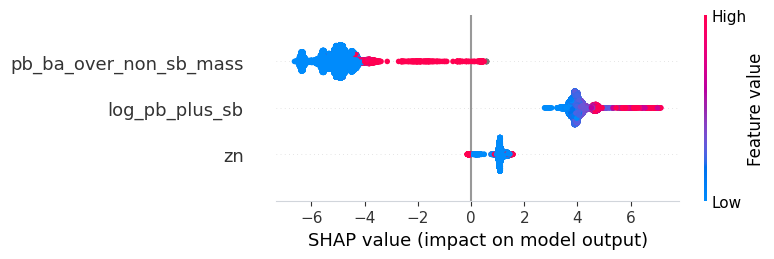

In [ ]:
sb_flagged_idx = np.where(sb_mask & (preds_amb == 1))[0]

amb_explainer = shap.TreeExplainer(xgb_model)

shap_values_sb = amb_explainer.shap_values(X_amb[sb_flagged_idx])
shap.summary_plot(
    shap_values_sb, X_amb[sb_flagged_idx], feature_names=feature_amb_cols, max_display=3
)

In [ ]:
# Antimony SHAP attribution for the ambiguous GSR predictions.
# For every Sb-class particle that the model flagged as GSR, list the top 3
# features pushing the prediction toward GSR (largest positive SHAP).
sb_flagged_idx = np.where(sb_mask & (preds_amb == 1))[0]
print(f"Computing SHAP for {len(sb_flagged_idx)} Sb particles flagged as GSR...")

shap_sb = amb_explainer.shap_values(X_amb[sb_flagged_idx])

eng_amb_reset = eng_amb.reset_index(drop=True)
sb_records = []
for i, idx in enumerate(sb_flagged_idx):
    row = eng_amb_reset.iloc[idx]
    contributions = pd.Series(shap_sb[i], index=feature_amb_cols)
    top_pos = contributions.nlargest(3)
    sb_records.append(
        {
            "stub_id": row["stub_id"],
            "particle_id": row["particle_id"],
            "final_class": row["final_class"],
            "prob": probs_amb[idx],
            "top_feature_1": top_pos.index[0],
            "shap_1": top_pos.iloc[0],
            "top_feature_2": top_pos.index[1],
            "shap_2": top_pos.iloc[1],
            "top_feature_3": top_pos.index[2],
            "shap_3": top_pos.iloc[2],
        }
    )
sb_shap_df = pd.DataFrame(sb_records).sort_values("prob", ascending=False)
print("Top-15 highest-confidence Sb-flagged particles with SHAP attribution:")
print(sb_shap_df.head(15).to_string(index=False))
# sb_shap_df.to_csv('xgb_sb_amb_shap_attribution.csv', index=False)

# Aggregate: which features most often drive these Sb-class flags?
sb_top_feature_counts = sb_shap_df["top_feature_1"].value_counts()
print(f"Which features most often drive Sb-class GSR flags (top-1 SHAP):")
print(sb_top_feature_counts.head(10))

### Ambiguous Particle Viz

In [ ]:
for cls in ["Sb", "Pb", "Ba", "Sr"]:
    p = probs_amb[eng_amb["final_class"] == cls]
    print(cls, (p < 0.5).mean(), ((p >= 0.5) & (p < 0.94)).mean(), (p >= 0.94).mean())

Sb 0.350218897889009 0.5567007568372356 0.09308034527375529
Pb 0.9577506623736144 0.03803153254838595 0.004217805077999691
Ba 0.9956091714551341 0.001052902763309699 0.00333792578155628
Sr 0.9986749305407139 0.0012395811070741612 8.548835221201111e-05


In [ ]:
"""
Ambiguous Particles — Confidence Breakdown
XGBoost and NN predictions on 506,682 single-element particles excluded from training.

Two separate figures (XGB and NN), each with one bar per class (Sb, Pb, Ba, Sr),
segmented by confidence band. The thresholds differ between models:
  XGB: P < 0.5 / 0.5 <= P < 0.94 / P >= 0.94
  NN : P < 0.2 / 0.2 <= P <= 0.8 / P > 0.8
"""

# --- Data -------------------------------------------------------------------

classes = ["Sb", "Pb", "Ba", "Sr"]
n_per_class = [225676, 168334, 89277, 23395]

# Neural Network - from Table 9 in the Baseline report (P<0.2 / 0.2-0.8 / >0.8)
nn_conf_non = [97.8, 98.2, 99.5, 99.8]
nn_uncertain = [0.4, 0.0, 0.2, 0.1]
nn_pred_gsr = [1.8, 1.8, 0.3, 0.0]

# XGBoost (calculated in previous cell)
xgb_conf_non = [35.0, 95.8, 99.6, 99.9]
xgb_uncertain = [55.7, 3.8, 0.01, 0.1]
xgb_pred_gsr = [9.3, 0.4, 0.3, 0.0]

# --- Style ------------------------------------------------------------------

# Colorblind-safe traffic-light palette
color_non = "#44AA99"  # Tol muted teal-green - confident Non-GSR
color_unc = "#DDCC77"  # Tol sandy yellow - uncertain
color_gsr = "#D55E00"  # Okabe-Ito vermillion - predicted GSR

plt.rcParams.update(
    {
        "font.size": 11,
        "font.family": "sans-serif",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#888880",
        "axes.labelcolor": "#3d3d3a",
        "xtick.color": "#3d3d3a",
        "ytick.color": "#3d3d3a",
    }
)

# --- Plot helper ------------------------------------------------------------


def plot_confidence(
    conf_non, uncertain, pred_gsr, title, title_color, band_labels, show_legend=True
):
    fig, ax = plt.subplots(figsize=(7.5, 5.2))
    x = np.arange(len(classes))
    bar_w = 0.35

    ax.bar(x, conf_non, bar_w, color=color_non, label=band_labels[0])
    ax.bar(x, uncertain, bar_w, bottom=conf_non, color=color_unc, label=band_labels[1])
    bottoms_gsr = [c + u for c, u in zip(conf_non, uncertain)]
    ax.bar(
        x, pred_gsr, bar_w, bottom=bottoms_gsr, color=color_gsr, label=band_labels[2]
    )

    ax.set_title(
        title, fontsize=14, fontweight="bold", pad=14, loc="left", color=title_color
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{c}\n{n / 1000:.1f}K" for c, n in zip(classes, n_per_class)], fontsize=10
    )
    ax.set_ylim(0, 105)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.set_ylabel("Share of particles in class", fontsize=11)
    ax.grid(axis="y", alpha=0.18, linewidth=0.5)
    ax.set_axisbelow(True)

    for i, (cn, un, gs) in enumerate(zip(conf_non, uncertain, pred_gsr)):
        if gs >= 1.0:
            ax.annotate(
                f"{gs:.1f}%",
                xy=(i, cn + un + gs),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center",
                fontsize=10,
                fontweight="medium",
                color=color_gsr,
            )

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles=handles[::-1],
            labels=labels[::-1],
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            ncol=1,
            frameon=False,
            fontsize=10,
        )

    plt.tight_layout()
    plt.savefig(
        "outputs/overfitting_ablation_ambiguous__plot.png", dpi=150, bbox_inches="tight"
    )


plt.show()

# --- XGBoost ----------------------------------------------------------------
plot_confidence(
    xgb_conf_non,
    xgb_uncertain,
    xgb_pred_gsr,
    title="XGBoost",
    title_color=INK,
    band_labels=[
        "Confident Non-GSR",
        "Uncertain",
        "Predicted GSR",
    ],
    show_legend=False,
)

# --- Neural Network ---------------------------------------------------------
plot_confidence(
    nn_conf_non,
    nn_uncertain,
    nn_pred_gsr,
    title="Neural Net",
    title_color=INK,
    band_labels=[
        "Confident Non-GSR",
        "Uncertain",
        "Predicted GSR",
    ],
)

In [ ]:
sb_flagged_idx = np.where(sb_mask & (preds_amb == 1))[0]

amb_explainer = shap.TreeExplainer(xgb_model)
shap_values_sb = amb_explainer.shap_values(X_amb[sb_flagged_idx])

# Slice down to just log_pb_plus_sb
log_idx = feature_amb_cols.index("log_pb_plus_sb")
shap_subset = shap_values_sb[:, [log_idx]]
X_subset = X_amb[sb_flagged_idx][:, [log_idx]]

shap.summary_plot(
    shap_subset,
    X_subset,
    feature_names=["log_pb_plus_sb"],
    show=False,
)

fig = plt.gcf()
ax = plt.gca()

# Drop the default y-tick label, put feature name inside the plot just right of the y-axis
ax.set_title(
    "Impact on GSR Prediction for Ambiguous Antimony",
    fontsize=11,
    color="#1F2937",
    pad=10,
)
ax.set_yticklabels([])
ax.text(
    0.03,
    0.5,
    "log_pb_plus_sb",
    transform=ax.transAxes,
    ha="left",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#1F2937",
)

# Trim the x-axis label
ax.set_xlabel("SHAP value", fontsize=10, color="#9CA1AA")

# Hide the y-axis spine and tick marks (label stays)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", labelsize=6)

# SHAP draws an axvline at x=0 - remove it
for line in list(ax.lines):
    xd = np.asarray(line.get_xdata())
    if xd.size > 0 and np.allclose(xd, 0):
        line.remove()

# Shrink the colorbar text ("Feature value", "High", "Low")
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(labelsize=7)
    if cbar_ax.get_ylabel():
        cbar_ax.set_ylabel(cbar_ax.get_ylabel(), fontsize=7)

# GSR / Non-GSR direction cues
ax.text(
    0.0,
    -0.30,
    "← Non-GSR",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    color="#1F2937",
)
ax.text(
    1.0,
    -0.30,
    "GSR →",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold",
    color="#37311F",
)

plt.savefig(
    "outputs/overfitting_ablation_ambiguous__impact_on_gsr_prediction_for_ambiguous_antimony.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()